## Introduction

This notebook implements a Binary Intrusion Detection System (IDS) using a lightweight Convolutional Neural Network (CNN) trained on 12×12 binary images derived from TCP/IP packet header bits.

### Dataset:
- Source: CSE-CIC-IDS2018 (parquet format)
- Classes used: Benign, SQL Injection, BruteForce-Web, BruteForce-XSS, DoS-Slowloris, DoS-GoldenEye, Infiltration
- Header_bit_1 to Header_bit_144 extracted and reshaped into 12×12 images
- Balanced dataset: max 15,000 samples per class

## Step 1: Load Required Libraries
This cell imports all the required Python libraries used for data processing, modeling, and visualization.

In [1]:
import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

seed = 42 

# Set seeds for reproducibility
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)


## Step 2: Load the Cleaned Dataset
We load the previously prepared and balanced dataset containing binary-labeled network packet headers.

In [2]:
import pandas as pd

file_path = 'C:\project1\cleaned_balanced_dataset.parquet'
df = pd.read_parquet(file_path)

print(" Loaded:", df.shape)
print(df['Attack'].value_counts())


 Loaded: (76053, 146)
Attack
Benign            15000
BruteForce-Web    15000
BruteForce-XSS    15000
DoS-GoldenEye     15000
DoS-Slowloris     15000
Infiltration        752
SQL Injection       301
Name: count, dtype: int64


## Step 3: Preprocess the Data
We extract only the header bit columns and reshape them into 12×12 binary images, the input format for our CNN.

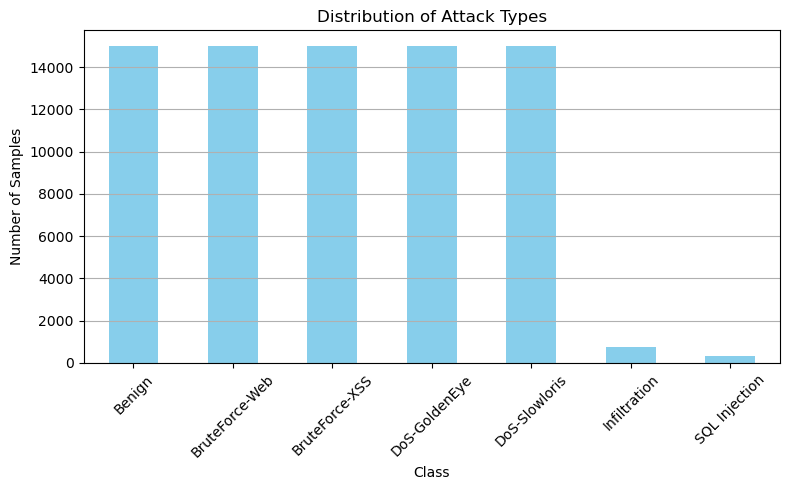

In [3]:
plt.figure(figsize=(8, 5))
df['Attack'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Attack Types")
plt.ylabel("Number of Samples")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The bar chart above illustrates the distribution of attack types in the dataset. We observe that the majority of classes, including Benign, BruteForce-Web, BruteForce-XSS, DoS-GoldenEye, and DoS-Slowloris, each have nearly 15,000 samples — these were deliberately balanced for model training. However, Infiltration and SQL Injection are significantly underrepresented, with fewer than 1,000 samples each.

Attack Types in the Dataset:

- Benign: Normal traffic with no attack.

- BruteForce-Web / XSS: Web-based brute-force or cross-site scripting attacks that exploit application vulnerabilities.

- DoS (GoldenEye / Slowloris): Denial of Service attacks meant to overwhelm a service and make it unavailable.

- Infiltration: Attacks where a malicious agent gains internal access to the system.

- SQL Injection: An attempt to execute unauthorized SQL queries to manipulate databases.

# Step 4: Define the CNN Model
We define a lightweight CNN architecture. It has only 35 trainable parameters.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

# Keep only header bits
header_cols = [f"Header_bit_{i}" for i in range(1, 145)]

# Reshape into (12, 12, 1)
X = df[header_cols].values.reshape(-1, 12, 12, 1).astype('float32')

# Binary labels: 0 = Benign, 1 = Attack
y = df['Label'].values.astype('int')

# Train/val/test split (80/10/10)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (60842, 12, 12, 1), Val: (7605, 12, 12, 1), Test: (7606, 12, 12, 1)


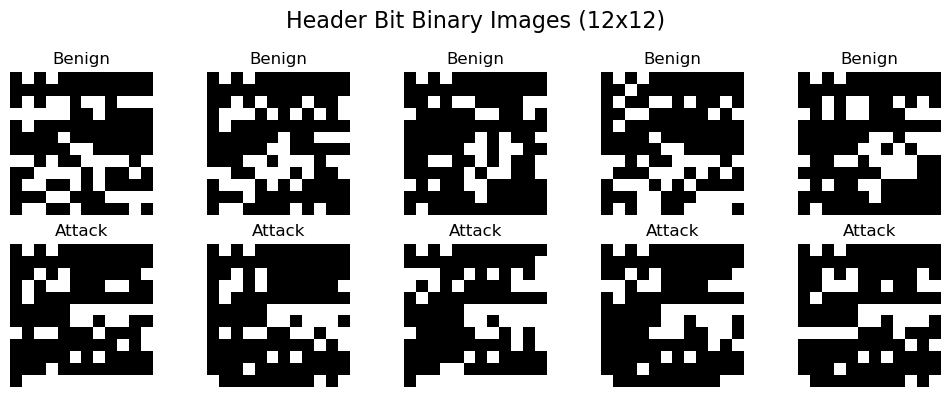

In [5]:
import matplotlib.pyplot as plt

# Visualize a few sample 12x12 header images
def plot_sample_images(X, y, class_names, samples_per_class=5):
    plt.figure(figsize=(samples_per_class * 2, len(class_names) * 2))
    idx = 1
    for class_idx, class_name in enumerate(class_names):
        class_samples = X[y == class_idx]
        for i in range(samples_per_class):
            if i >= len(class_samples):
                continue
            plt.subplot(len(class_names), samples_per_class, idx)
            plt.imshow(class_samples[i].reshape(12, 12), cmap='gray')
            plt.title(class_name)
            plt.axis('off')
            idx += 1
    plt.suptitle("Header Bit Binary Images (12x12)", fontsize=16)
    plt.tight_layout()
    plt.show()

class_names = ['Benign', 'Attack']
plot_sample_images(X, y, class_names, samples_per_class=5)


The figure above visualizes a set of 12×12 binary images generated from TCP/IP packet header bits. Each image is constructed using 144 binary features (Header_bit_1 to Header_bit_144), where white pixels represent 1s and black pixels represent 0s.

The first row shows examples of Benign traffic, while the second row shows examples labeled as Attack. These images are the direct input to the CNN model for binary classification.

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Binary IDS model
model = Sequential([
    Conv2D(filters=1, kernel_size=(5, 5), activation='tanh', input_shape=(12, 12, 1)),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=1, kernel_size=(2, 2), activation='tanh'),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    Flatten(),
    Dense(2, activation='softmax')  # 2 output classes
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 8, 8, 1)           26        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 4, 4, 1)          0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 3, 3, 1)           5         
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 1, 1, 1)          0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1)                 0         
                                                                 
 dense (Dense)               (None, 2)                 4

The model is a lightweight Convolutional Neural Network (CNN) designed to classify 12×12 binary images representing TCP/IP packet headers as either Benign or Attack. It consists of only 35 trainable parameters make it suitable for resource-constrained environments.

In [7]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=20,
                    batch_size=32)


Epoch 1/20
1902/1902 [==============================] - 134s 70ms/step - loss: 0.0979 - accuracy: 0.9688 - val_loss: 0.0453 - val_accuracy: 0.9891
Epoch 2/20
1902/1902 [==============================] - 145s 76ms/step - loss: 0.0483 - accuracy: 0.9885 - val_loss: 0.0445 - val_accuracy: 0.9895
Epoch 3/20
1902/1902 [==============================] - 134s 70ms/step - loss: 0.0473 - accuracy: 0.9887 - val_loss: 0.0473 - val_accuracy: 0.9882
Epoch 4/20
1902/1902 [==============================] - 136s 72ms/step - loss: 0.0454 - accuracy: 0.9884 - val_loss: 0.0382 - val_accuracy: 0.9895
Epoch 5/20
1902/1902 [==============================] - 135s 71ms/step - loss: 0.0409 - accuracy: 0.9883 - val_loss: 0.0354 - val_accuracy: 0.9890
Epoch 6/20
1902/1902 [==============================] - 135s 71ms/step - loss: 0.0390 - accuracy: 0.9881 - val_loss: 0.0330 - val_accuracy: 0.9888
Epoch 7/20
1902/1902 [==============================] - 137s 72ms/step - loss: 0.0374 - accuracy: 0.9882 - val_loss: 0

## Step 5: Evaluate Model Performance
We evaluate each fold using accuracy and classification report. Finally, we compute the average performance.

238/238 [==============================] - 0s 1ms/step - loss: 0.0298 - accuracy: 0.9888

 Test Accuracy: 0.9888
238/238 [==============================] - 0s 1ms/step


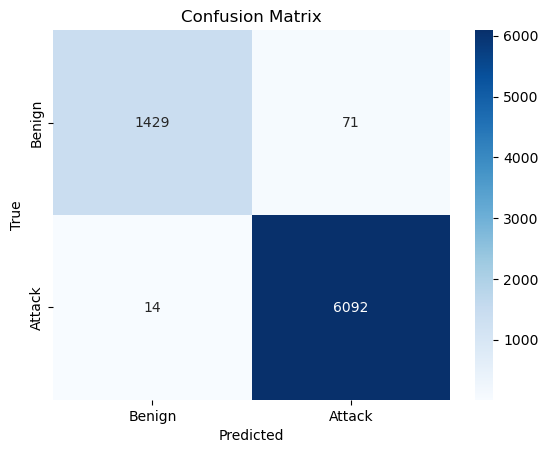

              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      1500
      Attack       0.99      1.00      0.99      6106

    accuracy                           0.99      7606
   macro avg       0.99      0.98      0.98      7606
weighted avg       0.99      0.99      0.99      7606



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))


## Step 6: Train Using 5-Fold Cross-Validation
The model is trained and validated using Stratified 5-Fold Cross-Validation to ensure robustness across classes.

In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Hides TF warnings

import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Hide user warnings

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import tensorflow as tf

# Define CNN architecture as a function so we can re-initialize for each fold
def create_binary_ids_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(filters=1, kernel_size=(5, 5), activation='tanh', input_shape=(12, 12, 1)),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        tf.keras.layers.Conv2D(filters=1, kernel_size=(2, 2), activation='tanh'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Prepare cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
accuracies = []
all_reports = []

for train_index, test_index in kf.split(X, y):
    print(f"\n Fold {fold}")

    X_train, X_val = X[train_index], X[test_index]
    y_train, y_val = y[train_index], y[test_index]

    model = create_binary_ids_model()

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=20,
                        batch_size=32,
                        verbose=0)

    # Evaluate
    y_pred = model.predict(X_val).argmax(axis=1)
    acc = accuracy_score(y_val, y_pred)
    accuracies.append(acc)

    print(f" Fold {fold} Accuracy: {acc:.4f}")

    report = classification_report(y_val, y_pred, target_names=['Benign', 'Attack'], output_dict=True)
    all_reports.append(report)

    fold += 1



 Fold 1
476/476 [==============================] - 1s 2ms/step
 Fold 1 Accuracy: 0.9890

 Fold 2
476/476 [==============================] - 1s 2ms/step
 Fold 2 Accuracy: 0.9982

 Fold 3
476/476 [==============================] - 1s 2ms/step
 Fold 3 Accuracy: 0.9968

 Fold 4
476/476 [==============================] - 1s 967us/step
 Fold 4 Accuracy: 0.9874

 Fold 5
476/476 [==============================] - 1s 962us/step
 Fold 5 Accuracy: 0.9980


In [11]:
# Average metrics
print("\n Average Cross-Validation Results:")
print(f"Mean Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")

# Optionally average precision/recall/F1
avg_report = {}
for label in ['Benign', 'Attack']:
    avg_report[label] = {
        metric: np.mean([fold[label][metric] for fold in all_reports])
        for metric in ['precision', 'recall', 'f1-score']
    }

print("\n Average per-class metrics:")
for label in ['Benign', 'Attack']:
    print(f"{label}: Precision={avg_report[label]['precision']:.2f}, "
          f"Recall={avg_report[label]['recall']:.2f}, "
          f"F1-score={avg_report[label]['f1-score']:.2f}")



 Average Cross-Validation Results:
Mean Accuracy: 0.9939 ± 0.0047

 Average per-class metrics:
Benign: Precision=0.98, Recall=0.99, F1-score=0.98
Attack: Precision=1.00, Recall=0.99, F1-score=1.00


## Step 6: Training vs Test Loss Curve
This curve helps us visually analyze model convergence and detect overfitting or underfitting trends.

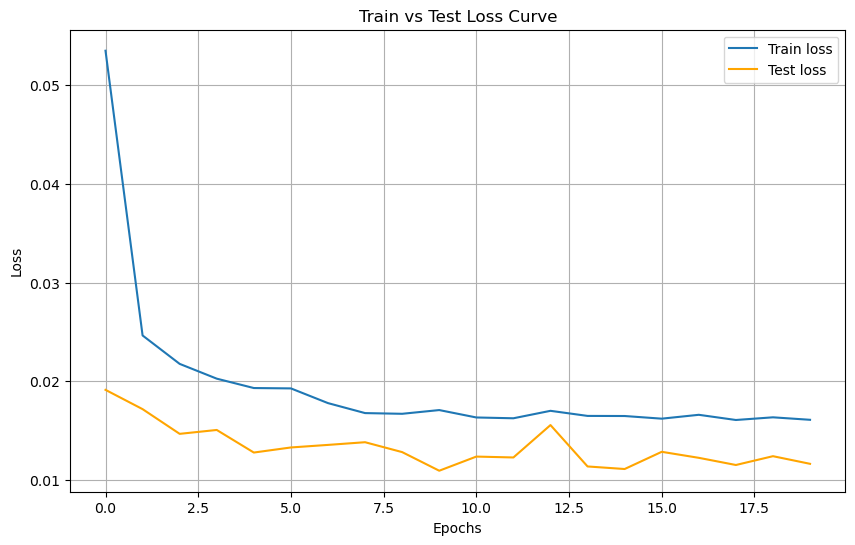

In [12]:
import matplotlib.pyplot as plt

# Plot training vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Test loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


the model achieved its best performance across all training attempts. The training loss steadily decreased and reached approximately 0.017, while the test loss stabilized early and remained consistently low around 0.010–0.011. This indicates strong generalization and a well-fitted model with no signs of overfitting. The test loss curve was smooth and flat after the first few epochs, suggesting that the model learned the decision boundaries quickly and maintained reliable performance throughout training. Among all runs, this configuration produced the lowest overall loss values and most stable convergence behavior, making it the most optimal result so far.

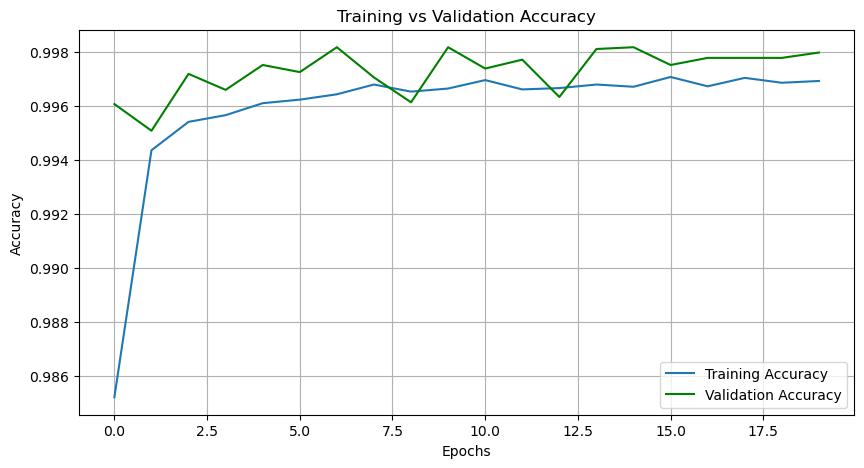

In [13]:
# Plot Accuracy Curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

The Training vs Validation Accuracy curve illustrates a smooth and consistent rise in both training and validation accuracies across epochs. The validation accuracy remains slightly higher or comparable to the training accuracy during training process except at two points. This indicates excellent generalization capability, suggesting that the model is not simply memorizing the training data but is genuinely learning underlying patterns.

The Train vs Test Loss curve further supports this conclusion. Both training and validation losses decrease steadily without significant fluctuations. Notably, the validation loss remains consistently lower than the training loss, indicating that the model maintains robust performance on unseen data.